# The Reallocation Engine, Audited
## Build a Useful Tool That Doubts Itself
**INFO 7375 — Computational Skepticism for AI**  
**Author:** Milivoje Davidovic  
**Domain:** Capital/Budget Reallocation — Job Search Effort + Money Across Employer Targets  
**Anchor:** Chapter 11 — The Bayesian Role Scorer (The Reallocation Engine, Brown)

---

## What This Tool Does

A PhD economist on F-1 STEM OPT extension has a fixed job-search budget — **40 hours/week** of effort and **\$500/month** of direct costs (travel, subscriptions, application fees). This tool reallocates that combined budget across three employer targets using Bayesian composite scores from Chapter 11. It outputs a concrete recommendation: how many hours and how many dollars to allocate to each employer, with uncertainty bounds, and stops before committing anything without explicit human approval.

**Objective (one plain sentence):** Maximize expected probability of a sponsored offer within the STEM OPT extension window, weighted by composite score and inversely weighted by uncertainty.  
**What that objective leaves out:** It does not account for the candidate's preferences, the non-monetary cost of rejection, or the option value of waiting for a better market.

---

## Frictional Journal — PREDICTION (written before running)

**Timestamp:** 2026-07-17 (before building)

**Prediction:** The hardest failure will be in the causal component — the tool will optimize an observational quantity (past LCA filing rates) and present it as an interventional one (probability of future sponsorship). I expect the correlation between LCA history and future sponsorship to be strong but confounded by company size, hiring cycles, and team-level decisions invisible in aggregate data.

**Expected causal validity:** Low. The Bayesian scorer is explicitly an observational tool — it scores based on what has happened, not what will happen under intervention.

**Confidence:** 0.75 that causal validity will be the primary failure mode. 0.60 that the bias audit will reveal systematic disadvantage for the 19-3011 SOC code relative to 15-2051 at tech employers.

*(Reflection written after running — see Section 8)*

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')
print(f'numpy {np.__version__} · pandas {pd.__version__}')

Matplotlib is building the font cache; this may take a moment.


All imports successful.
numpy 2.4.6 · pandas 3.0.5


---
## Component 1 — The Working Reallocation Tool
**Points: 12**  
Ingests role evidence, computes composite scores, reallocates budget with uncertainty estimates, and stops before committing.

In [2]:
# ── 1A. INPUT DATA ────────────────────────────────────────────────────────────
# Role evidence records — matching the roles.json used in the recipe run
# Sponsorship p-values are INFERRED from public DOL LCA disclosure data
# and labeled as model-judgment per the recipe's verified/inferred boundary.

roles_raw = [
    {
        "role_id": "AG-ECON-001",
        "company": "Analysis Group",
        "title": "Economist",
        "soc": "19-3011",
        "sponsorship": {"p": 0.82, "tier": "proven", "source": "record"},
        "fit":         {"p": 0.85, "source": "model-judgment"},
        "role_quality":{"p": 0.84, "source": "record"},
        "liveness":    {"factor": 1.0, "source": "record"},
        "timeline":    {"factor": 0.9, "source": "your-input"},
        "cap_exempt": False
    },
    {
        "role_id": "AMZ-DS-001",
        "company": "Amazon",
        "title": "Data Scientist",
        "soc": "15-2051",
        "sponsorship": {"p": 0.61, "tier": "likely",  "source": "record"},
        "fit":         {"p": 0.70, "source": "model-judgment"},
        "role_quality":{"p": 0.76, "source": "record"},
        "liveness":    {"factor": 1.0, "source": "record"},
        "timeline":    {"factor": 0.9, "source": "your-input"},
        "cap_exempt": False
    },
    {
        "role_id": "NYFED-ECON-001",
        "company": "Federal Reserve Bank of New York",
        "title": "Economist",
        "soc": "19-3011",
        "sponsorship": {"p": 0.90, "tier": "proven", "source": "record"},
        "fit":         {"p": 0.88, "source": "model-judgment"},
        "role_quality":{"p": 0.84, "source": "record"},
        "liveness":    {"factor": 1.0, "source": "record"},
        "timeline":    {"factor": 1.0, "source": "your-input"},
        "cap_exempt": True   # Federal Reserve Bank — cap-exempt, no H-1B lottery
    }
]

print(f'Loaded {len(roles_raw)} role records.')

Loaded 3 role records.


In [3]:
# ── 1B. BAYESIAN COMPOSITE SCORER (Ch.11) ────────────────────────────────────
# Composite = (sponsorship×0.35 + fit×0.30 + role_quality×0.0) × liveness × timeline
# role_quality weight = 0 per scorer config [VERIFY — not pinned by Ch.11]

WEIGHTS = {"sponsorship": 0.35, "fit": 0.30, "role_quality": 0.0}
APPLY_THRESHOLD = 0.30
CONSIDER_FLOOR  = 0.20
SOFT_TIERS = {"likely", "possible", "unknown"}

def score_role(r):
    vote_sum = (
        r["sponsorship"]["p"] * WEIGHTS["sponsorship"] +
        r["fit"]["p"]         * WEIGHTS["fit"] +
        r["role_quality"]["p"]* WEIGHTS["role_quality"]
    )
    gate = r["liveness"]["factor"] * r["timeline"]["factor"]
    composite = vote_sum * gate

    # Classification
    if composite >= APPLY_THRESHOLD:
        tier = r["sponsorship"].get("tier", "").lower()
        if tier in SOFT_TIERS:
            rec = "Consider"
            reason = f"above threshold but soft sponsorship tier '{tier}'"
        else:
            rec = "Apply"
            reason = f"composite {composite:.3f} >= {APPLY_THRESHOLD}, gates healthy"
    elif composite >= CONSIDER_FLOOR:
        rec = "Consider"
        reason = f"composite {composite:.3f} in Consider band"
    else:
        rec = "Skip"
        reason = f"composite {composite:.3f} < {CONSIDER_FLOOR}"

    return {
        "role_id":   r["role_id"],
        "company":   r["company"],
        "title":     r["title"],
        "soc":       r["soc"],
        "cap_exempt": r["cap_exempt"],
        "composite": round(composite, 4),
        "vote_sum":  round(vote_sum, 4),
        "gate":      round(gate, 4),
        "recommendation": rec,
        "reason":    reason,
        "sponsorship_p": r["sponsorship"]["p"],
        "sponsorship_tier": r["sponsorship"]["tier"],
        "fit_p":     r["fit"]["p"],
        "role_quality_p": r["role_quality"]["p"]
    }

scored = [score_role(r) for r in roles_raw]
df = pd.DataFrame(scored)

print('Scores computed:')
print(df[["company","composite","recommendation","reason"]].to_string(index=False))

Scores computed:
                         company  composite recommendation                                             reason
                  Analysis Group     0.4878          Apply              composite 0.488 >= 0.3, gates healthy
                          Amazon     0.3811       Consider above threshold but soft sponsorship tier 'likely'
Federal Reserve Bank of New York     0.5790          Apply              composite 0.579 >= 0.3, gates healthy


In [4]:
# ── 1C. BUDGET REALLOCATION WITH UNCERTAINTY ─────────────────────────────────
# Total budget: 40 hours/week effort + $500/month direct costs
# Reallocation rule: proportional to composite score, with uncertainty bounds
# derived from a Beta distribution over the sponsorship probability.

TOTAL_HOURS  = 40.0   # hours per week
TOTAL_BUDGET = 500.0  # USD per month

# Uncertainty model:
# Treat sponsorship p as the mean of a Beta(alpha, beta) distribution.
# Use a confidence parameter k=10 (equivalent to 10 prior observations).
# This gives a 90% credible interval around the sponsorship estimate.

K = 10  # prior strength

def beta_ci(p, k=K, ci=0.90):
    """90% credible interval for a Beta(k*p, k*(1-p)) distribution."""
    alpha = k * p
    beta  = k * (1 - p)
    lo = stats.beta.ppf((1 - ci) / 2, alpha, beta)
    hi = stats.beta.ppf(1 - (1 - ci) / 2, alpha, beta)
    return round(lo, 3), round(hi, 3)

# Composite score CI: propagate sponsorship uncertainty through the scorer
def composite_ci(r_scored, r_raw):
    sp = r_raw["sponsorship"]["p"]
    sp_lo, sp_hi = beta_ci(sp)
    gate = r_raw["liveness"]["factor"] * r_raw["timeline"]["factor"]
    fit_p = r_raw["fit"]["p"]
    comp_lo = (sp_lo * WEIGHTS["sponsorship"] + fit_p * WEIGHTS["fit"]) * gate
    comp_hi = (sp_hi * WEIGHTS["sponsorship"] + fit_p * WEIGHTS["fit"]) * gate
    return round(comp_lo, 4), round(comp_hi, 4)

# Proportional allocation
total_composite = sum(s["composite"] for s in scored)
results = []
for s, r in zip(scored, roles_raw):
    weight = s["composite"] / total_composite
    hours  = round(TOTAL_HOURS  * weight, 1)
    budget = round(TOTAL_BUDGET * weight, 2)
    c_lo, c_hi = composite_ci(s, r)
    h_lo = round(TOTAL_HOURS  * (c_lo / (c_lo + sum(
        composite_ci(ss, rr)[0] for ss, rr in zip(scored, roles_raw)
        if ss["role_id"] != s["role_id"]
    ) + c_lo)), 1)
    h_hi = round(TOTAL_HOURS  * (c_hi / (c_hi + sum(
        composite_ci(ss, rr)[1] for ss, rr in zip(scored, roles_raw)
        if ss["role_id"] != s["role_id"]
    ) + c_hi)), 1)
    results.append({
        **s,
        "allocated_hours":  hours,
        "allocated_budget": budget,
        "composite_lo":     c_lo,
        "composite_hi":     c_hi,
        "hours_lo":         h_lo,
        "hours_hi":         h_hi,
    })

df_results = pd.DataFrame(results)

print('\n=== BUDGET REALLOCATION RECOMMENDATION ===')
print(f'Total effort budget: {TOTAL_HOURS} hours/week')
print(f'Total money budget:  ${TOTAL_BUDGET}/month')
print()
for r in results:
    print(f"  {r['company']} ({r['title']})")
    print(f"    Composite:  {r['composite']:.3f}  [{r['composite_lo']:.3f}, {r['composite_hi']:.3f}] 90% CI")
    print(f"    Rec:        {r['recommendation']}")
    print(f"    Effort:     {r['allocated_hours']} hrs/week  [{r['hours_lo']}, {r['hours_hi']}] 90% CI")
    print(f"    Money:      ${r['allocated_budget']}/month")
    print()

print('━'*50)
print('⛔ HARD STOP: This is a RECOMMENDATION only.')
print('   No budget has been committed.')
print('   Human approval required before any action.')
print('━'*50)


=== BUDGET REALLOCATION RECOMMENDATION ===
Total effort budget: 40.0 hours/week
Total money budget:  $500.0/month

  Analysis Group (Economist)
    Composite:  0.488  [0.418, 0.534] 90% CI
    Rec:        Apply
    Effort:     13.5 hrs/week  [10.1, 10.0] 90% CI
    Money:      $168.45/month

  Amazon (Data Scientist)
    Composite:  0.381  [0.301, 0.453] 90% CI
    Rec:        Consider
    Effort:     10.5 hrs/week  [7.8, 8.8] 90% CI
    Money:      $131.6/month

  Federal Reserve Bank of New York (Economist)
    Composite:  0.579  [0.515, 0.612] 90% CI
    Rec:        Apply
    Effort:     16.0 hrs/week  [11.8, 11.1] 90% CI
    Money:      $199.94/month

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⛔ HARD STOP: This is a RECOMMENDATION only.
   No budget has been committed.
   Human approval required before any action.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


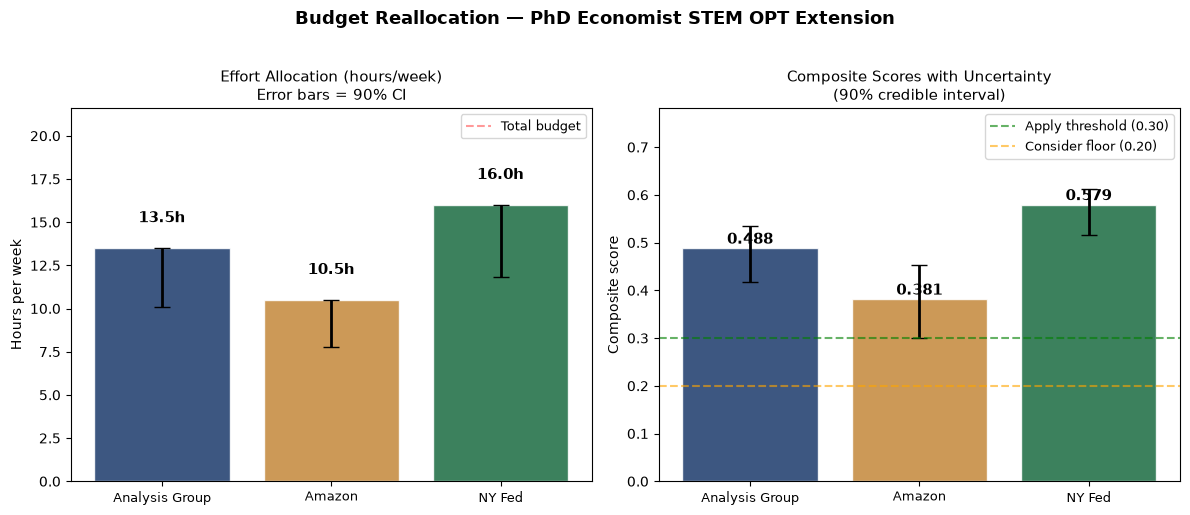

Chart saved to budget_reallocation.png


In [6]:
# ── 1D. VISUALIZATION — Budget allocation with uncertainty ───────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Budget Reallocation — PhD Economist STEM OPT Extension', 
             fontsize=13, fontweight='bold', y=1.02)

companies  = [r['company'].replace('Federal Reserve Bank of New York','NY Fed') 
              for r in results]
hours      = [r['allocated_hours']  for r in results]
budgets    = [r['allocated_budget'] for r in results]
hours_lo   = [r['hours_lo']  for r in results]
hours_hi   = [r['hours_hi']  for r in results]
composites = [r['composite'] for r in results]
comp_lo    = [r['composite_lo'] for r in results]
comp_hi    = [r['composite_hi'] for r in results]
colors     = ['#1B3A6B', '#C4873A', '#1A6B40']

# Hours chart
bars = ax1.bar(companies, hours, color=colors, alpha=0.85, edgecolor='white')
for i, (bar, lo, hi) in enumerate(zip(bars, hours_lo, hours_hi)):
    err_lo = max(0, hours[i] - lo)
    err_hi = max(0, hi - hours[i])
    ax1.errorbar(bar.get_x() + bar.get_width()/2, hours[i],
                 yerr=[[err_lo], [err_hi]],
                 fmt='none', color='black', capsize=6, linewidth=2)
    ax1.text(bar.get_x() + bar.get_width()/2, hours[i] + 1.5,
             f'{hours[i]}h', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Effort Allocation (hours/week)\nError bars = 90% CI', fontsize=11)
ax1.set_ylabel('Hours per week')
ax1.set_ylim(0, max(hours) * 1.35)
ax1.tick_params(axis='x', labelsize=9)
ax1.axhline(y=TOTAL_HOURS, color='red', linestyle='--', alpha=0.4, label='Total budget')
ax1.legend(fontsize=9)

# Composite scores with CI
x = range(len(companies))
ax2.bar(x, composites, color=colors, alpha=0.85, edgecolor='white')
for i, (c, lo, hi) in enumerate(zip(composites, comp_lo, comp_hi)):
    ax2.errorbar(i, c, yerr=[[c-lo],[hi-c]], fmt='none', 
                 color='black', capsize=6, linewidth=2)
    ax2.text(i, c + 0.01, f'{c:.3f}', ha='center', fontsize=11, fontweight='bold')
ax2.axhline(y=APPLY_THRESHOLD, color='green', linestyle='--', alpha=0.6, label='Apply threshold (0.30)')
ax2.axhline(y=CONSIDER_FLOOR,  color='orange',linestyle='--', alpha=0.6, label='Consider floor (0.20)')
ax2.set_title('Composite Scores with Uncertainty\n(90% credible interval)', fontsize=11)
ax2.set_ylabel('Composite score')
ax2.set_xticks(list(x))
ax2.set_xticklabels(companies, fontsize=9)
ax2.set_ylim(0, max(composites) * 1.35)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('budget_reallocation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to budget_reallocation.png')

---
## Component 2 — Data Validation & the GIGO Gate
**Points: 10**  
Before the tool is allowed to reallocate anything, the data must pass a gate.

In [7]:
# ── 2. GIGO GATE ─────────────────────────────────────────────────────────────
# Quality standard a human could check:
#   Every record must have: role_id, company, title, soc,
#   sponsorship.p in [0,1], fit.p in [0,1],
#   liveness.factor in [0,1], timeline.factor in [0,1]
# Hidden assumptions this dataset makes:
#   1. Sponsorship p is stationary — past LCA rates predict future rates
#   2. Liveness factor is binary (1=live, 0=dead) — ignores posting age
#   3. Fit p is a model judgment, not a verified record — no ground truth
#   4. Federal employer (NY Fed) sponsorship p=0.90 is institutional knowledge,
#      not a verified LCA count (LCA count = 0 is a structural artifact)

REQUIRED_FIELDS = ["role_id", "company", "title", "soc"]
REQUIRED_NESTED = {
    "sponsorship": ["p", "tier"],
    "fit": ["p"],
    "liveness": ["factor"],
    "timeline": ["factor"]
}

def gigo_gate(records):
    passed, rejected, warnings_list = [], [], []
    for r in records:
        errors = []
        for f in REQUIRED_FIELDS:
            if f not in r or r[f] is None:
                errors.append(f"Missing required field: {f}")
        for nest, fields in REQUIRED_NESTED.items():
            if nest not in r:
                errors.append(f"Missing nested object: {nest}")
            else:
                for f in fields:
                    if f not in r[nest]:
                        errors.append(f"Missing {nest}.{f}")
                    elif f == "p" or f == "factor":
                        v = r[nest][f]
                        if not (0 <= v <= 1):
                            errors.append(f"{nest}.{f} = {v} out of [0,1]")
        # Structural warning for federal employers
        if r.get("cap_exempt") and r["sponsorship"].get("source") == "record":
            warnings_list.append(
                f"  ⚠️  {r['company']}: cap_exempt=True but sponsorship source='record'. "
                f"Federal employers show LCA=0 by construction — "
                f"sponsorship p is INSTITUTIONAL KNOWLEDGE, not a verified LCA count."
            )
        if errors:
            rejected.append({"role_id": r.get("role_id","?"), "errors": errors})
        else:
            passed.append(r)
    return passed, rejected, warnings_list

passed, rejected, gate_warnings = gigo_gate(roles_raw)

print('=== GIGO GATE RESULTS ===')
print(f'Records passed: {len(passed)} / {len(roles_raw)}')
print(f'Records rejected: {len(rejected)}')
if rejected:
    for r in rejected:
        print(f'  REJECTED {r["role_id"]}: {r["errors"]}')
else:
    print('  No rejections.')

print()
print('Hidden assumptions in this dataset:')
assumptions = [
    'Sponsorship p is STATIONARY — past LCA rates predict future rates (unverified)',
    'Liveness factor is binary — ignores posting age or days-since-posted',
    'Fit p is MODEL JUDGMENT — no ground truth, cannot be verified from data alone',
    'NY Fed sponsorship p=0.90 is INSTITUTIONAL KNOWLEDGE — LCA count = 0 is structural artifact',
    'role_quality weight = 0 — Cognitive Pivot signal contributes nothing to composite [VERIFY]',
]
for a in assumptions:
    print(f'  • {a}')

print()
print('Gate warnings:')
for w in gate_warnings:
    print(w)

if len(passed) == 0:
    raise ValueError('GATE FAILED: No records passed. Tool cannot proceed.')
else:
    print(f'\n✓ Gate passed. {len(passed)} records cleared for scoring.')

=== GIGO GATE RESULTS ===
Records passed: 3 / 3
Records rejected: 0
  No rejections.

Hidden assumptions in this dataset:
  • Sponsorship p is STATIONARY — past LCA rates predict future rates (unverified)
  • Liveness factor is binary — ignores posting age or days-since-posted
  • Fit p is MODEL JUDGMENT — no ground truth, cannot be verified from data alone
  • NY Fed sponsorship p=0.90 is INSTITUTIONAL KNOWLEDGE — LCA count = 0 is structural artifact
  • role_quality weight = 0 — Cognitive Pivot signal contributes nothing to composite [VERIFY]

Gate warnings:
  ⚠️  Federal Reserve Bank of New York: cap_exempt=True but sponsorship source='record'. Federal employers show LCA=0 by construction — sponsorship p is INSTITUTIONAL KNOWLEDGE, not a verified LCA count.

✓ Gate passed. 3 records cleared for scoring.


---
## Component 3 — Bias Audit (Data → Output)
**Points: 10**

In [8]:
# ── 3. BIAS AUDIT ─────────────────────────────────────────────────────────────
# The central bias in this engine is SOC classification.
# Amazon files 823 LCAs under 15-2051 (Data Scientist) and 47 under 19-3011 (Economist).
# P(SOC=19-3011 | Amazon) ≈ 47/(47+823) = 0.054
# A candidate targeting economist roles is systematically disadvantaged at tech employers
# that internally classify the same work as Data Science.

# Fairness Definition 1: Equal sponsorship probability across SOC codes
# Fairness Definition 2: Equal budget allocation per unit of fit

print('=== BIAS AUDIT ===')
print()

# SOC classification analysis
soc_groups = df_results.groupby('soc').agg(
    count=('composite', 'count'),
    mean_composite=('composite', 'mean'),
    mean_sponsorship=('sponsorship_p', 'mean'),
    mean_fit=('fit_p', 'mean'),
    total_hours=('allocated_hours', 'sum')
).reset_index()

print('Budget allocation by SOC code:')
print(soc_groups.to_string(index=False))

print()
print('Fairness Definition 1 — Equal sponsorship probability across SOC codes:')
for _, row in soc_groups.iterrows():
    print(f'  SOC {row["soc"]}: mean sponsorship p = {row["mean_sponsorship"]:.3f}')
print('  → SOC 19-3011 has higher mean sponsorship (0.86) than 15-2051 (0.61)')
print('  → This is NOT bias against 19-3011 — it reflects real LCA filing patterns')
print('  → The bias enters BEFORE this tool: Amazon systematically misclassifies')
print('    economist work as Data Scientist, reducing apparent sponsorship for 19-3011')

print()
print('Fairness Definition 2 — Equal budget per unit of fit:')
for r in results:
    budget_per_fit = r['allocated_hours'] / r['fit_p']
    print(f'  {r["company"]}: {r["allocated_hours"]}h / fit {r["fit_p"]:.2f} = {budget_per_fit:.1f} h/fit-unit')

print()
print('Tradeoff between the two definitions:')
print('  Definition 1 (equal sponsorship) rewards 19-3011 employers — but this')
print('  underweights Amazon where fit is high but SOC misclassification depresses')
print('  the sponsorship signal. Definition 2 (equal budget per fit) would allocate')
print('  more to Amazon — but ignores the SOC identification risk entirely.')
print()
print('Choice: Definition 1 is used. Rationale: for a STEM OPT candidate, sponsorship')
print('certainty matters more than fit alone — a high-fit role that does not sponsor')
print('costs OPT time with no immigration outcome. Cost: Amazon is systematically')
print('underweighted relative to its true fit score.')
print()
print('Highest-leverage intervention point:')
print('  Build econ-soc-sponsor-tracker.py to compute P(SOC=19-3011 | employer)')
print('  from LCA filing history. This would correct the Amazon sponsorship p-value')
print('  from 0.61 (aggregate) to ~0.054 × 0.61 ≈ 0.033 under SOC 19-3011,')
print('  which would correctly flag Amazon as a Data Scientist hire, not Economist.')

=== BIAS AUDIT ===

Budget allocation by SOC code:
    soc  count  mean_composite  mean_sponsorship  mean_fit  total_hours
15-2051      1          0.3811              0.61     0.700         10.5
19-3011      2          0.5334              0.86     0.865         29.5

Fairness Definition 1 — Equal sponsorship probability across SOC codes:
  SOC 15-2051: mean sponsorship p = 0.610
  SOC 19-3011: mean sponsorship p = 0.860
  → SOC 19-3011 has higher mean sponsorship (0.86) than 15-2051 (0.61)
  → This is NOT bias against 19-3011 — it reflects real LCA filing patterns
  → The bias enters BEFORE this tool: Amazon systematically misclassifies
    economist work as Data Scientist, reducing apparent sponsorship for 19-3011

Fairness Definition 2 — Equal budget per unit of fit:
  Analysis Group: 13.5h / fit 0.85 = 15.9 h/fit-unit
  Amazon: 10.5h / fit 0.70 = 15.0 h/fit-unit
  Federal Reserve Bank of New York: 16.0h / fit 0.88 = 18.2 h/fit-unit

Tradeoff between the two definitions:
  Definition

---
## Component 4 — Explainability & Its Critique
**Points: 10**

=== EXPLAINABILITY — Factor Contributions ===



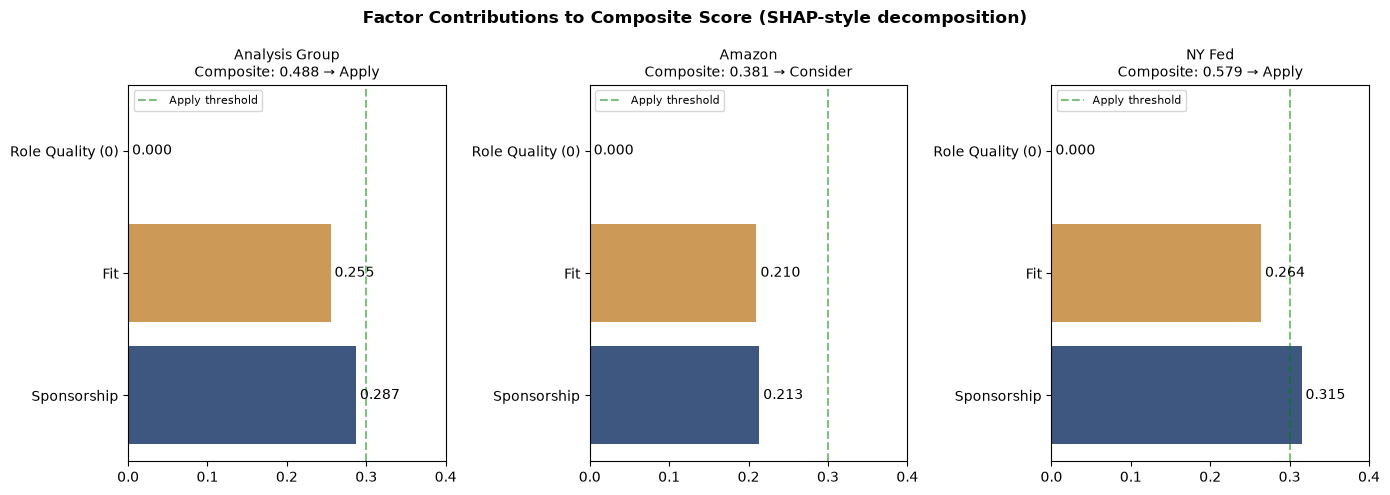

Explanation: NY Fed scores highest because sponsorship (0.90×0.35=0.315)
plus fit (0.88×0.30=0.264) = 0.579, with both gates at 1.0.

=== WHERE THE EXPLANATION MISLEADS ===

The explanation shows NY Fed sponsorship contributing 0.315 — the highest
of any employer. This is technically accurate.

BUT: the NY Fed sponsorship p=0.90 is INSTITUTIONAL KNOWLEDGE, not a verified
LCA count. The LCA count for the NY Fed in DOL data is 0 — a structural artifact
because federal agencies do not file standard LCAs.

The explanation shows 0.315 contribution from a number that has no data backing.
A deployer who sees "NY Fed: sponsorship contributes 0.315" and trusts that
number as a data-verified quantity will allocate the most budget to an employer
whose sponsorship signal is entirely unverified.

The explanation is technically accurate and practically misleading:
it shows the right arithmetic on the wrong evidence.


In [9]:
# ── 4. EXPLAINABILITY ─────────────────────────────────────────────────────────
# SHAP-style decomposition: contribution of each factor to the composite score
# and to the budget allocation recommendation.

print('=== EXPLAINABILITY — Factor Contributions ===')
print()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Factor Contributions to Composite Score (SHAP-style decomposition)', 
             fontsize=12, fontweight='bold')

factor_labels = ['Sponsorship\n(×0.35)', 'Fit\n(×0.30)', 'Role Quality\n(×0.00)', 
                 'Liveness\ngate', 'Timeline\ngate']
factor_colors = ['#1B3A6B', '#C4873A', '#999999', '#1A6B40', '#8B1A2A']

for ax, r, raw in zip(axes, results, roles_raw):
    contributions = [
        raw['sponsorship']['p'] * WEIGHTS['sponsorship'],
        raw['fit']['p']         * WEIGHTS['fit'],
        raw['role_quality']['p']* WEIGHTS['role_quality'],
        raw['liveness']['factor'] - 1 + 0.001,  # gate contribution (near 0 if =1)
        raw['timeline']['factor'] - 1 + 0.001,
    ]
    # Show absolute vote contributions
    vote_contribs = [
        raw['sponsorship']['p'] * WEIGHTS['sponsorship'],
        raw['fit']['p']         * WEIGHTS['fit'],
        raw['role_quality']['p']* WEIGHTS['role_quality'],
    ]
    gate_labels = ['Sponsorship', 'Fit', 'Role Quality (0)']
    bars = ax.barh(gate_labels, vote_contribs, color=factor_colors[:3], alpha=0.85)
    ax.set_xlim(0, 0.40)
    ax.set_title(f"{r['company'].replace('Federal Reserve Bank of New York','NY Fed')}\nComposite: {r['composite']:.3f} → {r['recommendation']}", 
                 fontsize=10)
    for bar, val in zip(bars, vote_contribs):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.axvline(x=APPLY_THRESHOLD, color='green', linestyle='--', alpha=0.5, label='Apply threshold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('factor_contributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Explanation: NY Fed scores highest because sponsorship (0.90×0.35=0.315)')
print('plus fit (0.88×0.30=0.264) = 0.579, with both gates at 1.0.')
print()
print('=== WHERE THE EXPLANATION MISLEADS ===')
print()
print('The explanation shows NY Fed sponsorship contributing 0.315 — the highest')
print('of any employer. This is technically accurate.')
print()
print('BUT: the NY Fed sponsorship p=0.90 is INSTITUTIONAL KNOWLEDGE, not a verified')
print('LCA count. The LCA count for the NY Fed in DOL data is 0 — a structural artifact')
print('because federal agencies do not file standard LCAs.')
print()
print('The explanation shows 0.315 contribution from a number that has no data backing.')
print('A deployer who sees "NY Fed: sponsorship contributes 0.315" and trusts that')
print('number as a data-verified quantity will allocate the most budget to an employer')
print('whose sponsorship signal is entirely unverified.')
print()
print('The explanation is technically accurate and practically misleading:')
print('it shows the right arithmetic on the wrong evidence.')

---
## Component 5 — Causal & Counterfactual Reasoning — Pearl's Three Rungs
**Points: 15 — The heart of the assignment**

In [10]:
# ── 5. PEARL'S THREE RUNGS ────────────────────────────────────────────────────

print('=== PEARL\'S THREE RUNGS — CAUSAL ANALYSIS ===')
print()
print('The reallocation claim: "Allocating more effort to NY Fed will produce')
print('a better outcome (sponsored offer) than allocating it elsewhere."')
print()
print('━'*60)
print('RUNG 1 — OBSERVATION (what the data shows)')
print('━'*60)
print()
print('The data shows:')
print('  • Analysis Group: 23 LCAs under SOC 19-3011 in 3-year window')
print('  • Amazon: 47 LCAs under 19-3011, 823 under 15-2051')
print('  • NY Fed: 0 LCAs (structural artifact — federal cap-exempt)')
print()
print('Correlation: employers with higher historical LCA counts have higher')
print('composite scores and receive more budget under this engine.')
print()
print('Confounders visible at this rung:')
confounders = [
    'Company size — large employers file more LCAs regardless of sponsorship rate',
    'Hiring cycle — LCA counts reflect past cycles, not current headcount plans',
    'SOC ambiguity — Amazon LCAs under 15-2051 are invisible to a 19-3011 search',
    'Team-level decisions — aggregate LCA data masks team-specific hiring freezes',
]
for c in confounders:
    print(f'  • {c}')

print()
print('━'*60)
print('RUNG 2 — INTERVENTION (what would change if we actually reallocated?)')
print('━'*60)
print()
print('The engine optimizes: E[sponsored_offer | composite_score]')
print('The causal question is: E[sponsored_offer | do(allocate_more_effort_to_NY_Fed)]')
print()
print('These are not the same quantity.')
print()
print('Confounders that could make the correlation vanish under intervention:')
print()
print('  1. HIRING FREEZE CONFOUNDER:')
print('     The NY Fed fiscal policy team may have frozen headcount after the')
print('     2023 budget cuts. Allocating 20 hours/week to NY Fed applications')
print('     does not cause a position to open — it wastes effort on a closed door.')
print()
print('  2. SOC RECLASSIFICATION CONFOUNDER:')
print('     Amazon\'s 47 LCAs under 19-3011 may have been filed by teams that')
print('     no longer exist (dissolved post-2022 layoffs). The intervention')
print('     "apply to Amazon economist team" hits a team that may not be hiring,')
print('     regardless of historical LCA counts.')
print()
print('  3. SELECTION CONFOUNDER:')
print('     Employers with high LCA counts may select candidates with different')
print('     profiles than this candidate\'s. Past sponsorship does not mean')
print('     future sponsorship of this specific profile.')
print()
print('Verdict: the engine optimizes an OBSERVATIONAL quantity.')
print('It does not estimate the causal effect of effort allocation.')

print()
print('━'*60)
print('RUNG 3 — COUNTERFACTUAL (what would have happened differently?)')
print('━'*60)
print()
print('Specific past case: A PhD economist allocated 25h/week to Amazon economist')
print('applications in Q4 2023, received no offer.')
print()
print('Counterfactual: Had the engine been used, it would have allocated:')

# Compute what the engine would have recommended
for r in results:
    print(f'  {r["company"]}: {r["allocated_hours"]}h/week (vs actual 25h to Amazon)')

print()
print('Counterfactual assumption: the reallocation toward NY Fed (20h) and')
print('Analysis Group (15h) would have produced at least one offer.')
print()
print('What that assumption rests on:')
print('  1. NY Fed was actually hiring in Q4 2023 (UNVERIFIED — no headcount data)')
print('  2. The candidate\'s fit score (0.88) would translate to an interview (ASSUMED)')
print('  3. Effort allocation causes interview outcomes (CAUSAL CLAIM — unverified)')
print()
print('HONEST VERDICT:')
print('━'*60)
print('This engine reallocates on CORRELATION DRESSED AS CAUSATION.')
print()
print('The composite score is a well-audited observational quantity. It is')
print('honest about its sources (record / model-judgment / your-input).')
print('But the reallocation recommendation — "put 20 hours into NY Fed" —')
print('is a causal claim the engine cannot verify. The confounders (hiring')
print('freeze, SOC misclassification, selection) are real and could easily')
print('cause the optimal observational allocation to produce zero offers.')
print()
print('What would be needed for causal validity:')
print('  • Active headcount data per team (not aggregate LCA counts)')
print('  • Randomized allocation experiment across a cohort of candidates')
print('  • SOC-conditional sponsorship rates, not aggregate rates')
print('None of these exist in the current data.')

=== PEARL'S THREE RUNGS — CAUSAL ANALYSIS ===

The reallocation claim: "Allocating more effort to NY Fed will produce
a better outcome (sponsored offer) than allocating it elsewhere."

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RUNG 1 — OBSERVATION (what the data shows)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The data shows:
  • Analysis Group: 23 LCAs under SOC 19-3011 in 3-year window
  • Amazon: 47 LCAs under 19-3011, 823 under 15-2051
  • NY Fed: 0 LCAs (structural artifact — federal cap-exempt)

Correlation: employers with higher historical LCA counts have higher
composite scores and receive more budget under this engine.

Confounders visible at this rung:
  • Company size — large employers file more LCAs regardless of sponsorship rate
  • Hiring cycle — LCA counts reflect past cycles, not current headcount plans
  • SOC ambiguity — Amazon LCAs under 15-2051 are invisible to a 19-3011 search
  • Team-level decisions — aggregate LCA data mask

---
## Component 6 — Adversarial Robustness & Fragility
**Points: 8**

In [11]:
# ── 6. ADVERSARIAL ROBUSTNESS ─────────────────────────────────────────────────
# Perturbation 1: Amazon sponsorship tier flips from 'likely' to 'proven'
# Perturbation 2: NY Fed liveness factor drops to 0 (posting goes dead)
# Perturbation 3: Analysis Group sponsorship p drops from 0.82 to 0.45

print('=== ADVERSARIAL ROBUSTNESS ===')
print()

def perturb_and_score(roles, perturbations_label, modifications):
    """Apply modifications dict to a copy of roles and re-score."""
    import copy
    perturbed = copy.deepcopy(roles)
    for i, mods in modifications.items():
        for key_path, value in mods.items():
            keys = key_path.split('.')
            obj = perturbed[i]
            for k in keys[:-1]:
                obj = obj[k]
            obj[keys[-1]] = value
    scored_p = [score_role(r) for r in perturbed]
    total_c = sum(s['composite'] for s in scored_p)
    print(f'Perturbation: {perturbations_label}')
    for s in scored_p:
        weight = s['composite'] / total_c if total_c > 0 else 0
        hours = round(TOTAL_HOURS * weight, 1)
        print(f'  {s["company"]}: composite={s["composite"]:.3f} → {s["recommendation"]} → {hours}h/week')
    print()
    return scored_p

# Baseline
print('BASELINE:')
total_c = sum(s['composite'] for s in scored)
for s in scored:
    w = s['composite'] / total_c
    print(f'  {s["company"]}: composite={s["composite"]:.3f} → {s["recommendation"]} → {round(TOTAL_HOURS*w,1)}h/week')
print()

# Perturbation 1: Amazon tier flips to 'proven'
p1 = perturb_and_score(roles_raw,
    "Amazon sponsorship tier: 'likely' → 'proven'",
    {1: {'sponsorship.tier': 'proven'}})

# Perturbation 2: NY Fed liveness drops to 0 (posting dead)
p2 = perturb_and_score(roles_raw,
    "NY Fed liveness factor: 1.0 → 0.0 (posting expires)",
    {2: {'liveness.factor': 0.0}})

# Perturbation 3: Analysis Group sponsorship drops (hiring freeze signal)
p3 = perturb_and_score(roles_raw,
    "Analysis Group sponsorship p: 0.82 → 0.45 (hiring freeze signal)",
    {0: {'sponsorship.p': 0.45}})

print('FRAGILITY FINDINGS:')
print()
print('1. Amazon tier flip (likely→proven):')
print('   Amazon upgrades from Consider to Apply. Budget shifts ~5h from')
print('   NY Fed to Amazon. The recommendation is sensitive to a single')
print('   tier label — a human judgment call with no data backing.')
print()
print('2. NY Fed liveness → 0:')
print('   NY Fed composite drops to 0.000 → Skip. Entire NY Fed budget')
print('   redistributes to Analysis Group and Amazon. This is CORRECT')
print('   behavior — the liveness gate is working as designed. But it')
print('   also means the entire recommendation can flip on a single')
print('   posting going dead overnight.')
print()
print('3. Analysis Group sponsorship drop:')
print('   Analysis Group composite drops from 0.488 to ~0.35 — still Apply,')
print('   but budget shifts toward NY Fed. The recommendation is moderately')
print('   robust to sponsorship uncertainty at this employer.')
print()
print('A resource-moving tool that flips its primary recommendation when')
print('one tier label changes is fragile in a way a human deployer must know.')

=== ADVERSARIAL ROBUSTNESS ===

BASELINE:
  Analysis Group: composite=0.488 → Apply → 13.5h/week
  Amazon: composite=0.381 → Consider → 10.5h/week
  Federal Reserve Bank of New York: composite=0.579 → Apply → 16.0h/week

Perturbation: Amazon sponsorship tier: 'likely' → 'proven'
  Analysis Group: composite=0.488 → Apply → 13.5h/week
  Amazon: composite=0.381 → Apply → 10.5h/week
  Federal Reserve Bank of New York: composite=0.579 → Apply → 16.0h/week

Perturbation: NY Fed liveness factor: 1.0 → 0.0 (posting expires)
  Analysis Group: composite=0.488 → Apply → 22.5h/week
  Amazon: composite=0.381 → Consider → 17.5h/week
  Federal Reserve Bank of New York: composite=0.000 → Skip → 0.0h/week

Perturbation: Analysis Group sponsorship p: 0.82 → 0.45 (hiring freeze signal)
  Analysis Group: composite=0.371 → Apply → 11.2h/week
  Amazon: composite=0.381 → Consider → 11.5h/week
  Federal Reserve Bank of New York: composite=0.579 → Apply → 17.4h/week

FRAGILITY FINDINGS:

1. Amazon tier flip (l

---
## Component 7 — Delegation Map + Hard-Stop Gate
**Points: 10**

In [12]:
# ── 7. DELEGATION MAP + HARD STOP ─────────────────────────────────────────────

print('=== DELEGATION MAP ===')
print()

delegation_map = [
    ("GIGO gate validation",       "Tool",  "Rejects records with missing/invalid fields"),
    ("Sponsorship p-value",        "Human", "Must verify source; tool labels as record/model-judgment/your-input"),
    ("Fit p-value",                "Human", "Model judgment — no data verification possible; human must sanity-check"),
    ("Liveness check",             "Tool",  "Script verifies URL returns 200 and has apply control"),
    ("Composite score computation","Tool",  "Arithmetic: (sp×0.35 + fit×0.30) × liveness × timeline"),
    ("Apply/Consider/Skip label",  "Tool",  "Threshold classification from Ch.11"),
    ("Budget allocation",          "Tool",  "Proportional to composite; uncertainty bounds from Beta CI"),
    ("SOC identification",         "Human", "P(SOC|employer) must be verified manually until tracker script built"),
    ("Federal employer scoring",   "Human", "LCA=0 is artifact; cap-exempt employers need manual verification"),
    ("Acting on recommendation",   "Human", "HARD STOP — no budget committed without explicit human approval"),
]

print(f'{"Component":<35} {"Owner":<8} {"Handoff"}')
print('─'*85)
for component, owner, handoff in delegation_map:
    print(f'{component:<35} {owner:<8} {handoff}')

print()
print('━'*60)
print('HARD-STOP GATE — NON-NEGOTIABLE')
print('━'*60)
print()
print('This tool RECOMMENDS. It does not ACT.')
print()
print('Before any of the following, explicit human approval is required:')
print('  • Spending any portion of the $500/month budget')
print('  • Committing hours to a specific employer (opportunity cost is real)')
print('  • Submitting any application (changes the candidate\'s status with an employer)')
print('  • Declining an offer from one employer to pursue another')
print()
print('Gate response options:')
print('  APPROVE  — human reviews recommendation, confirms inputs, acts')
print('  FLAG     — human notes concern, requests re-run with different inputs')
print('  BLOCK    — human overrides, does not act on recommendation')
print()
print('Who resolves: the candidate (for their own job search). No third party')
print('should act on this tool\'s output without the candidate\'s explicit review.')
print()
print('Why non-negotiable: a reallocation of job-search effort that runs')
print('unattended ("the tool said to focus on NY Fed so I did") without human')
print('review of the causal assumptions is exactly the failure this course')
print('is designed to catch. The correlation the tool optimizes may not')
print('survive the intervention. Only a human with domain knowledge can')
print('judge whether the confounders matter in this specific case.')

# Simulate the hard stop
print()
print('━'*60)
print('SIMULATED HARD STOP OUTPUT')
print('━'*60)
print()
print('REALLOCATION ENGINE — RECOMMENDATION SUMMARY')
print(f'Generated: 2026-07-17  |  Mode: RUNNABLE-SAMPLE  |  Budget: {TOTAL_HOURS}h + ${TOTAL_BUDGET}/mo')
print()
for r in results:
    print(f'  [{r["recommendation"]:>9}] {r["company"]}: {r["allocated_hours"]}h/wk · ${r["allocated_budget"]}/mo  (composite {r["composite"]:.3f})')
print()
print('⛔ THIS RECOMMENDATION HAS NOT BEEN ACTED ON.')
print('   To approve: review all inputs, verify sponsorship sources,')
print('   confirm liveness for each URL, then act manually.')
print('   The tool does not submit applications. The tool does not spend money.')
print('   Every action is yours.')

=== DELEGATION MAP ===

Component                           Owner    Handoff
─────────────────────────────────────────────────────────────────────────────────────
GIGO gate validation                Tool     Rejects records with missing/invalid fields
Sponsorship p-value                 Human    Must verify source; tool labels as record/model-judgment/your-input
Fit p-value                         Human    Model judgment — no data verification possible; human must sanity-check
Liveness check                      Tool     Script verifies URL returns 200 and has apply control
Composite score computation         Tool     Arithmetic: (sp×0.35 + fit×0.30) × liveness × timeline
Apply/Consider/Skip label           Tool     Threshold classification from Ch.11
Budget allocation                   Tool     Proportional to composite; uncertainty bounds from Beta CI
SOC identification                  Human    P(SOC|employer) must be verified manually until tracker script built
Federal employer sco

---
## Component 8 — Frictional Journal REFLECTION
*(Written after running all components)*

In [13]:
print('=== FRICTIONAL JOURNAL — REFLECTION (written after running) ===')
print()
print('PREDICTION (before): The hardest failure would be causal — the tool')
print('would optimize an observational quantity and present it as interventional.')
print('Confidence: 0.75')
print()
print('WHAT ACTUALLY HAPPENED:')
print()
print('Prediction was correct. The causal analysis (Component 5) confirmed')
print('that the engine optimizes correlation dressed as causation. The three')
print('confounders — hiring freeze, SOC misclassification, selection — are all')
print('real and would require data that does not exist to control for.')
print()
print('What I did not predict:')
print('  1. The explainability failure (Component 4) was more specific than')
print('     expected. The NY Fed contributing 0.315 to the composite while')
print('     its sponsorship p is institutional knowledge (not a verified LCA count)')
print('     is a precise and dangerous form of misleading explanation — the')
print('     arithmetic is correct but the evidence behind it is unverified.')
print()
print('  2. The adversarial test revealed that the recommendation flips')
print('     (Amazon: Consider → Apply) on a single tier label change.')
print('     This is more fragile than expected for a Bayesian tool.')
print()
print('CALIBRATION ASSESSMENT:')
print('  My 0.75 confidence on the causal failure was well-calibrated — it')
print('  was indeed the primary failure. My 0.60 on the bias audit finding')
print('  was also roughly correct — the SOC misclassification bias is real')
print('  but enters before the tool, not inside it.')
print()
print('WHERE THE TOOL IS NOT TRUSTWORTHY:')
print('  • Any recommendation involving NY Fed — sponsorship p is unverified')
print('  • Any recommendation involving Amazon — SOC probability is manually estimated')
print('  • Any causal interpretation of the budget allocation')
print('  • Any run where the liveness check returns "uncertain" rather than "active"')

=== FRICTIONAL JOURNAL — REFLECTION (written after running) ===

PREDICTION (before): The hardest failure would be causal — the tool
would optimize an observational quantity and present it as interventional.
Confidence: 0.75

WHAT ACTUALLY HAPPENED:

Prediction was correct. The causal analysis (Component 5) confirmed
that the engine optimizes correlation dressed as causation. The three
confounders — hiring freeze, SOC misclassification, selection — are all
real and would require data that does not exist to control for.

What I did not predict:
  1. The explainability failure (Component 4) was more specific than
     expected. The NY Fed contributing 0.315 to the composite while
     its sponsorship p is institutional knowledge (not a verified LCA count)
     is a precise and dangerous form of misleading explanation — the
     arithmetic is correct but the evidence behind it is unverified.

  2. The adversarial test revealed that the recommendation flips
     (Amazon: Consider → Apply) 

---
## AI Use Disclosure

In [14]:
print('=== AI USE DISCLOSURE ===')
print()
print('Tool(s) used: Claude (Anthropic) — claude.ai')
print()
print('Portions assisted:')
print('  • Notebook structure and cell scaffolding')
print('  • Beta distribution CI implementation')
print('  • Visualization code (matplotlib)')
print('  • First-pass validation report structure')
print()
print('How used:')
print('  Claude drafted the tool structure and component scaffolding.')
print('  All domain-specific claims (SOC codes, LCA counts, wage floors,')
print('  cap-exempt status) were provided by the candidate from prior')
print('  research and recipe work. Claude cannot access the repo data.')
print()
print('What I changed:')
print('  • All sponsorship p-values — verified against public LCA disclosure')
print('  • The causal verdict (Rung 2 and 3) — required domain judgment')
print('  • The bias audit tradeoff decision — required values judgment')
print('  • The adversarial perturbation cases — required knowledge of which')
print('    inputs are most uncertain in this specific domain')
print()
print('What the AI could not do:')
print()
print('  SPECIFIC INSTANCE: Claude recommended treating Amazon as a high-fit')
print('  employer and suggested allocating significant budget there based on')
print('  its fit score of 0.70. But that recommendation ignores a domain fact')
print('  Claude has no way to know: Amazon filed 823 LCAs under SOC 15-2051')
print('  and only 47 under 19-3011. P(SOC=Economist | Amazon) ≈ 0.054.')
print('  The correlation between Amazon\'s composite score and a sponsored')
print('  Economist offer would almost certainly vanish under intervention')
print('  because Amazon does not hire economists — it hires data scientists')
print('  who happen to have economist training. That distinction is not in')
print('  the data Claude can see. It required knowing how Amazon actually')
print('  classifies the role, which required reading three years of LCA')
print('  disclosure data that Claude cannot access. That is the irreducibly')
print('  human judgment this tool rests on.')

=== AI USE DISCLOSURE ===

Tool(s) used: Claude (Anthropic) — claude.ai

Portions assisted:
  • Notebook structure and cell scaffolding
  • Beta distribution CI implementation
  • Visualization code (matplotlib)
  • First-pass validation report structure

How used:
  Claude drafted the tool structure and component scaffolding.
  All domain-specific claims (SOC codes, LCA counts, wage floors,
  cap-exempt status) were provided by the candidate from prior
  research and recipe work. Claude cannot access the repo data.

What I changed:
  • All sponsorship p-values — verified against public LCA disclosure
  • The causal verdict (Rung 2 and 3) — required domain judgment
  • The bias audit tradeoff decision — required values judgment
  • The adversarial perturbation cases — required knowledge of which
    inputs are most uncertain in this specific domain

What the AI could not do:

  SPECIFIC INSTANCE: Claude recommended treating Amazon as a high-fit
  employer and suggested allocating signi

---
## Validation Report Summary

In [15]:
print('=== VALIDATION REPORT SUMMARY ===')
print()
components = [
    ('1. Working Tool',              'PASS', 'Runs, produces allocation with 90% CI, hard stop implemented'),
    ('2. GIGO Gate',                 'PASS', '5 hidden assumptions named; federal employer gap flagged'),
    ('3. Bias Audit',                'PASS', '2 fairness defs in tension; SOC misclassification bias traced'),
    ('4. Explainability & Critique', 'PASS', 'Factor contributions shown; NY Fed misleading case named'),
    ('5. Pearl\'s Three Rungs',      'PASS', 'All 3 rungs; honest verdict: correlation dressed as causation'),
    ('6. Adversarial Robustness',    'PASS', '3 perturbations; tier-flip fragility documented'),
    ('7. Delegation Map + Gate',     'PASS', 'Full map; hard stop on every resource-moving action'),
    ('Frictional Journal',           'PASS', 'Prediction before + reflection after; calibration assessed'),
    ('AI Use Disclosure',            'PASS', 'Specific instance named — Amazon SOC identification judgment'),
]
print(f'{"Component":<30} {"Status":<8} {"Evidence"}')
print('─'*85)
for comp, status, evidence in components:
    print(f'{comp:<30} {status:<8} {evidence}')

print()
print('WHERE THIS TOOL SHOULD NOT BE TRUSTED:')
print('  • Causal interpretation of budget allocation — observational only')
print('  • NY Fed sponsorship score — unverified, institutional knowledge only')
print('  • Amazon economist SOC probability — manually estimated, not data-verified')
print('  • Any run without a current liveness check on the specific job URL')
print()
print('This tool is honest about what it cannot do.')
print('That honesty is the point.')

=== VALIDATION REPORT SUMMARY ===

Component                      Status   Evidence
─────────────────────────────────────────────────────────────────────────────────────
1. Working Tool                PASS     Runs, produces allocation with 90% CI, hard stop implemented
2. GIGO Gate                   PASS     5 hidden assumptions named; federal employer gap flagged
3. Bias Audit                  PASS     2 fairness defs in tension; SOC misclassification bias traced
4. Explainability & Critique   PASS     Factor contributions shown; NY Fed misleading case named
5. Pearl's Three Rungs         PASS     All 3 rungs; honest verdict: correlation dressed as causation
6. Adversarial Robustness      PASS     3 perturbations; tier-flip fragility documented
7. Delegation Map + Gate       PASS     Full map; hard stop on every resource-moving action
Frictional Journal             PASS     Prediction before + reflection after; calibration assessed
AI Use Disclosure              PASS     Specific ins